In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import Simulation as sim
import scaling as sc
sb.set(context = 'notebook',font = 'serif',font_scale = 1.3)
sb.set_palette('Set2', 8)

#%matplotlib widget

In [24]:
G = sc.CGS.G

In [70]:
rp = np.loadtxt('../run067/output-00324.txt', usecols = (0,11,8,6,9))

In [17]:
rp.shape

(4096, 3)

1.8872369423524345e-15
(array([0, 1, 2, 3], dtype=int64),) [ 1.88723694e-15  9.88615097e-16  4.69390025e-16 ... -1.36158765e-27
 -1.35659408e-27 -1.35194365e-27]


(1700, 1750)

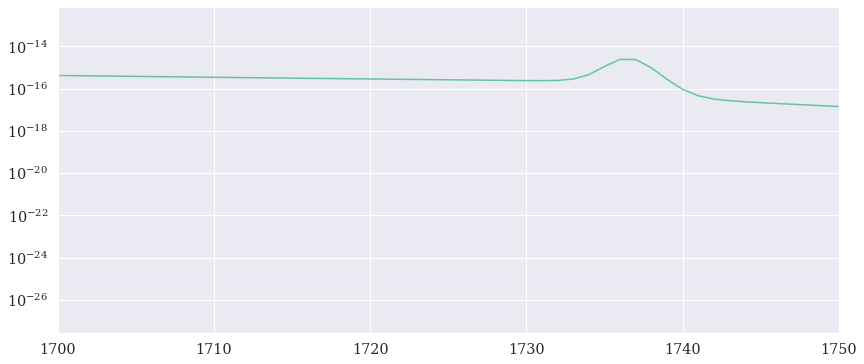

(2,)

In [55]:
dp.shape

(4096,)

In [ ]:
rp = np.loadtxt('../run067/output-00324.txt', usecols = (0,11,8,6,9))
cs = rp[:,4]
M = rp[:,2]
r = rp[:,0]
vkep = np.sqrt(G*M/r)
dm = M[1:] - M[:-1]
rho = rp[:,3]
dpdr = (rp[1:,1] - rp[:-1,1])/(rp[1:,0]-rp[:-1,0])


plt.figure(figsize = (14,6))

print(dpdr.max())
print(np.where(dpdr > 0), dpdr)

plt.plot(-dpdr)
plt.yscale('log')
plt.xlim([1700,1750])


dpdr = np.array([dpdr[0],dpdr])
np.array([dpdr[0],dpdr]).shape
dp = np.array([dpdr[0]].append(dpdr.tolist()))

dp = np.zeros(len(dpdr)+1)
dp[0] = dpdr[0] ; dp[1:] = dpdr

plt.figure(figsize = (14,6))
plt.plot(rho)
plt.yscale('log')

plt.figure(figsize = (14,6))
plt.plot(vkep)

plt.figure(figsize = (14,6))
plt.plot( 0.5*r*dp/(vkep*rho) )

plt.figure(figsize = (14,6))
plt.plot(cs**2/vkep*dp*rp[:,0]/rp[:,1]) # drift velocity

dpdr[0]


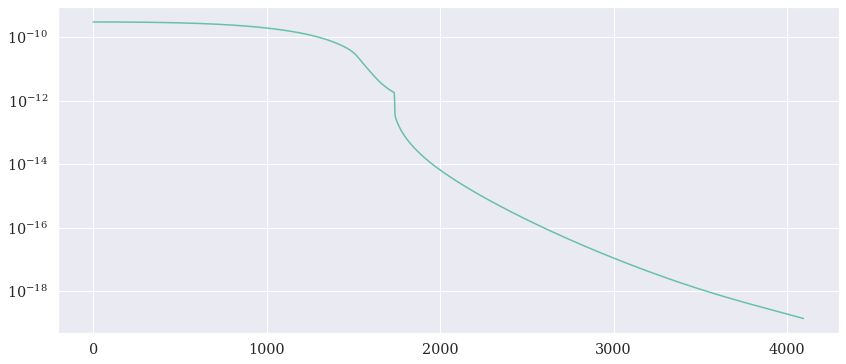

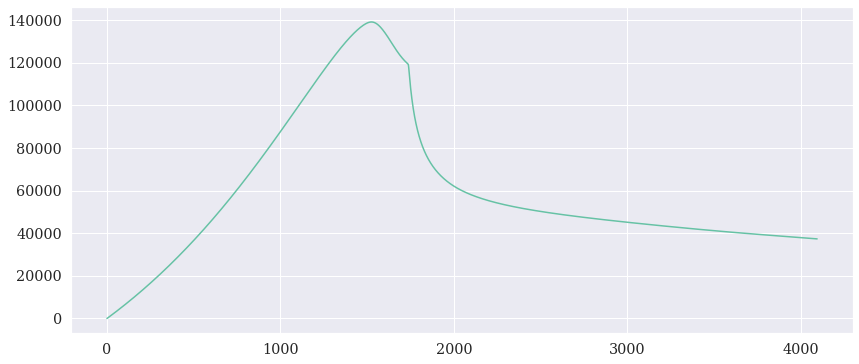

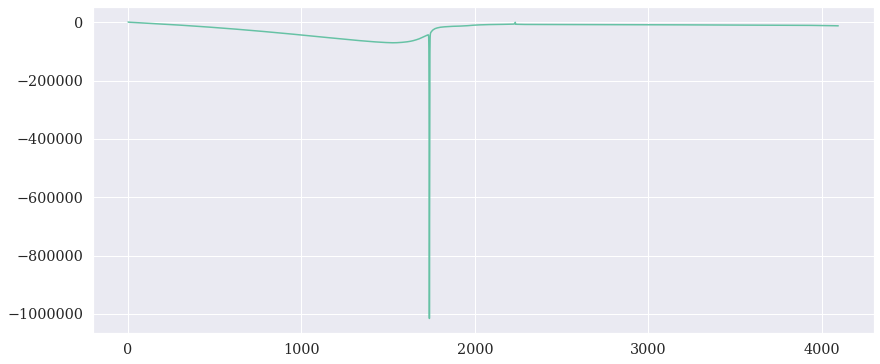

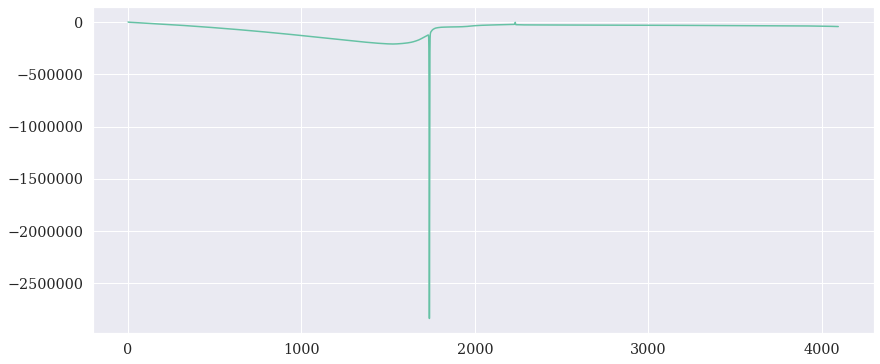

1.8872369423524345e-15

## Libaray Docstring

In [2]:
help(sim)

Help on module Simulation:

NAME
    Simulation - #%matplotlib widget

CLASSES
    builtins.object
        DataParticles
        DataSphere
        Particles
            Particles_Corrected
        save_particles
    
    class DataParticles(builtins.object)
     |  DataParticles(loadpath, env, skiprows=0, max_rows=None)
     |  
     |  # rc, vg, rhog , M, T 
     |  #  0   1     2   3  4
     |  
     |  Methods defined here:
     |  
     |  St(self, rm, s, snapid, rho_d=1.6)
     |  
     |  __init__(self, loadpath, env, skiprows=0, max_rows=None)
     |      Initialize self.  See help(type(self)) for accurate signature.
     |  
     |  search(self, rm)
     |  
     |  ----------------------------------------------------------------------
     |  Data descriptors defined here:
     |  
     |  __dict__
     |      dictionary for instance variables (if defined)
     |  
     |  __weakref__
     |      list of weak references to the object (if defined)
    
    class DataSphere(bui

## Data Sphere Docstring

In [3]:
help(sim.DataSphere)

Help on class DataSphere in module Simulation:

class DataSphere(builtins.object)
 |  DataSphere(loadpath, units, idstep=0, mu=2.42)
 |  
 |  # rc, vg, rhog , M, T 
 |  #  0   1     2   3  4
 |  
 |  Methods defined here:
 |  
 |  M(self, rmag)
 |  
 |  T(self, rmag)
 |  
 |  __init__(self, loadpath, units, idstep=0, mu=2.42)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  drag(self, r, s, rho_d=1.6)
 |      This is actually the inverse stopping time.
 |      so drag = 1/t_s
 |      rho_d = 1.6 g/cm^3
 |  
 |  rho(self, rmag)
 |  
 |  update(self)
 |  
 |  vg(self, r)
 |      TODO NOTE this needs to be a 2d vector, in cartesian corodiantes, this is the radial
 |  
 |  vgmag(self, rmag)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  dr
 |  
 |  dt
 |  
 |  dtsnap
 |  
 |  idstep
 |  
 |  interpolateM
 |  
 |  interpolateT
 |  
 |  interpolaterho
 |  
 |  interpolatesearch
 |  
 |

## DataParticles Docstring

In [4]:
help(sim.DataParticles)

Help on class DataParticles in module Simulation:

class DataParticles(builtins.object)
 |  DataParticles(loadpath, env, skiprows=0, max_rows=None)
 |  
 |  # rc, vg, rhog , M, T 
 |  #  0   1     2   3  4
 |  
 |  Methods defined here:
 |  
 |  St(self, rm, s, snapid, rho_d=1.6)
 |  
 |  __init__(self, loadpath, env, skiprows=0, max_rows=None)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  search(self, rm)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



# Plots

In [2]:
ginterface  = np.geomspace(1.42921456e-06, 1.42921456e-04, 20)

In [3]:
path = '../SimData/Fullrun_100/'

In [4]:
sphere = sim.DataSphere   ('../run_extracted/run067/', units = sc.CGS)
sphere._vg[:,:-1] = (sphere._rc[:,1:]-sphere._rc[:,:-1])/sphere.dt[None,:-1]
sphere.update()

In [33]:
rowrange = { 'skiprows' : 0,    # Start
             'max_rows' : 46 } # \# Lines to read after start
p        = sim.DataParticles(path, sphere, **rowrange)

In [72]:
v    = np.loadtxt(path + 'vx.txt'      ,**rowrange)
St   = np.loadtxt(path + 'St.txt'      ,**rowrange)
s    = np.loadtxt(path + 's.txt'       ,**rowrange)
grav = np.loadtxt(path + 'gravityx.txt',**rowrange)
M    = np.loadtxt(path + 'mass.txt'    ,**rowrange)

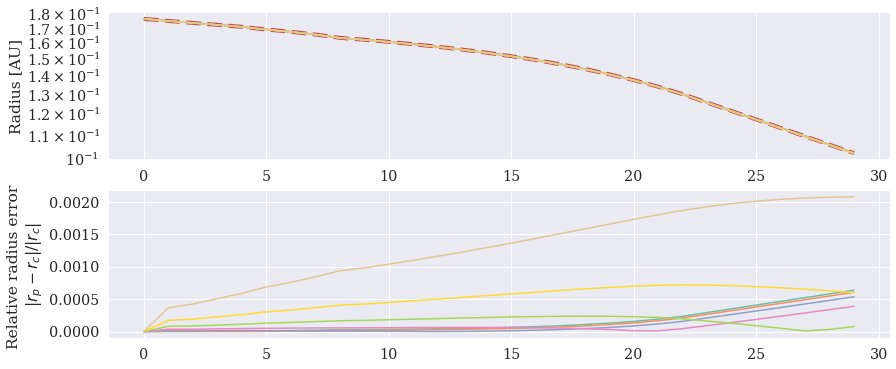

In [20]:
plt.figure( figsize = (14,6) )
I,J = 2,1

ax0 = plt.subplot(I, J, 1)
ax1 = plt.subplot(I, J, 2)


ax0.plot(sphere._rc[0,:len(p.r)]/sc.CGS.AU, 'r--', linewidth = 4)
for i in np.arange(0,19,3):
    ax0.plot(p.r[:,i]/sc.CGS.AU)
    ax1.plot( np.abs( p.r[:,i]-sphere._rc[0,:len(p.r)])/sphere._rc[0,:len(p.r)] )
    
    
ax0.set_yscale('log')
ax0.set_ylabel('Radius [AU]')

#ax1.set_yscale('log')
ax1.set_ylabel('Relative radius error \n'+ r'$|r_p - r_c|/|r_c|$')



plt.show()

In [38]:
D = sim.dust_to_gas_DataParticles(p,s.min(),1)

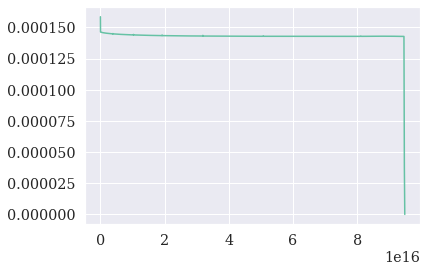

In [39]:
plt.plot(sphere._rc[:-1,300], D[0])

In [7]:
smask = p.s[0,:]== p.s[0,:].min()

In [216]:
rrr = sphere.rc[1000]
for idt ,dt in enumerate(sphere.dt[:45]):
    rrr = rrr + dt*(p.env._vg[1000,idt]+0.10)
print(rrr)

1832349671394763.5


In [196]:
rr = sphere.rc[1000]
for idt ,dt in enumerate(sphere.dt[:45]):
    rr = rr - dt*p.vg[idt+1,19000]
print(rr)

1832620549383284.5


In [226]:
path1 = '../SimData/Fullrun_1000/'
rowrange = { 'skiprows' : 0,    # Start
             'max_rows' : 250 } # \# Lines to read after start
p1        = sim.DataParticles(path1, sphere, **rowrange)

In [236]:
rrr = sphere.rc[1000]
for idt ,dt in enumerate(sphere.dt[:100]):
    rrr = rrr + dt*(p1.env._vg[1000,idt])
print(rrr)

1832028633594700.0


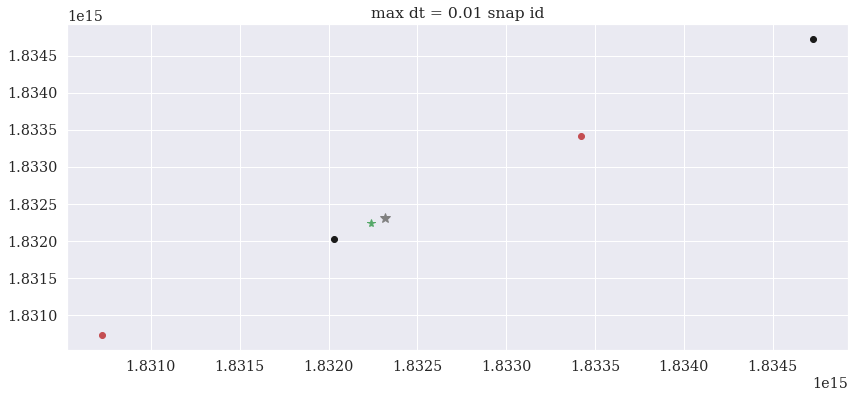

In [280]:
i = 45
plt.figure(figsize = (14,6))

rrr = sphere.rc[1000]
fudge = 0.09
for idt ,dt in enumerate(sphere.dt[:i]):
    rrr = rrr + dt*(p.env._vg[1000,idt]+fudge)

plt.plot(p.env._rc[1000:1002,i],p.env._rc[1000:1002,i],'ko')
plt.plot(p.env._re[1000:1002,i],p.env._re[1000:1002,i],'ro')
plt.title('max dt = 0.01 snap id')
plt.plot(p.r[i][smask][1000], p.r[i][smask][1000],'g*',markersize = 8)
plt.plot(rrr,rrr,'*',color= 'gray', markersize = 11)    

plt.show()

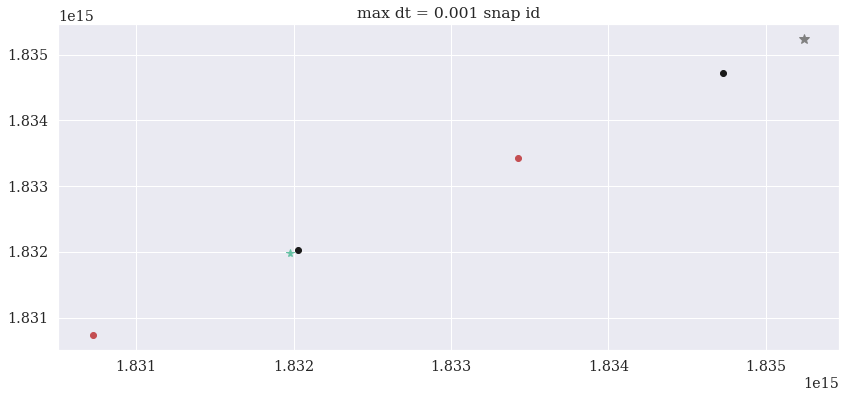

In [282]:
plt.figure(figsize = (14,6))
i = 45
rrr = sphere.rc[1000]
fudge = 1
for idt ,dt in enumerate(sphere.dt[:i]):
    rrr = rrr + dt*(p1.env._vg[1000,idt]+fudge)
    
plt.plot(rrr,rrr,'*',color= 'gray', markersize = 11)    
plt.plot(p1.env._rc[1000:1002,i],p1.env._rc[1000:1002,i],'ko')
plt.plot(p1.env._re[1000:1002,i],p1.env._re[1000:1002,i],'ro')
plt.plot(p1.r[i,19000],p1.r[i,19000],'*',markersize = 8)
plt.title('max dt = 0.001 snap id')
#plt.plot(rr,rr,'g*', markersize = 10)
plt.show()

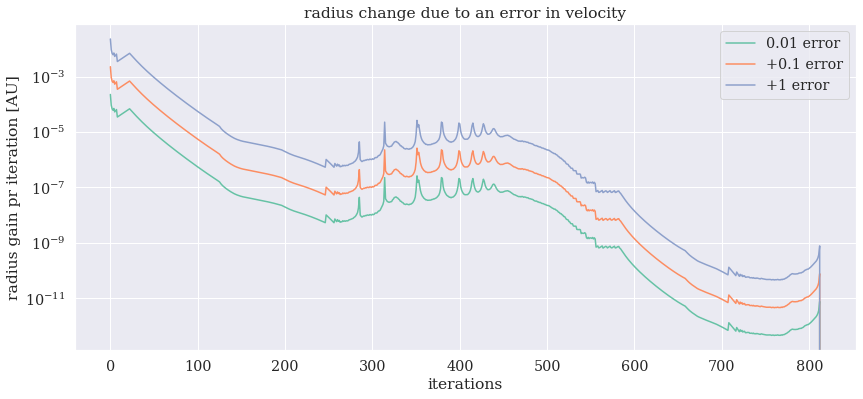

In [272]:
plt.figure(figsize = (14,6))
plt.plot(sphere.dt*0.01/p.units.AU ,label = '0.01 error')
plt.plot(sphere.dt*0.1 /p.units.AU ,label = '+0.1 error')
plt.plot(sphere.dt*1   /p.units.AU ,label = '+1 error')
plt.title('radius change due to an error in velocity')
plt.legend()
plt.ylabel('radius gain pr iteration [AU]')
plt.xlabel('iterations')

plt.yscale('log')


plt.show()

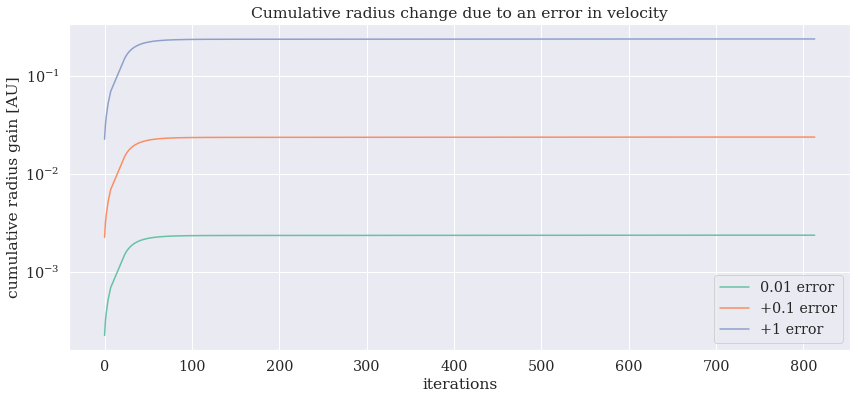

In [269]:
plt.figure(figsize = (14,6))
plt.plot(np.cumsum(sphere.dt*0.01/p.units.AU) ,label = '0.01 error')
plt.plot(np.cumsum(sphere.dt*0.1 /p.units.AU) ,label = '+0.1 error')
plt.plot(np.cumsum(sphere.dt*1   /p.units.AU) ,label = '+1 error')
plt.title('Cumulative radius change due to an error in velocity')
plt.legend()
plt.ylabel('cumulative radius gain [AU]')
plt.xlabel('iterations')

plt.yscale('log') # <--- scale


plt.show()

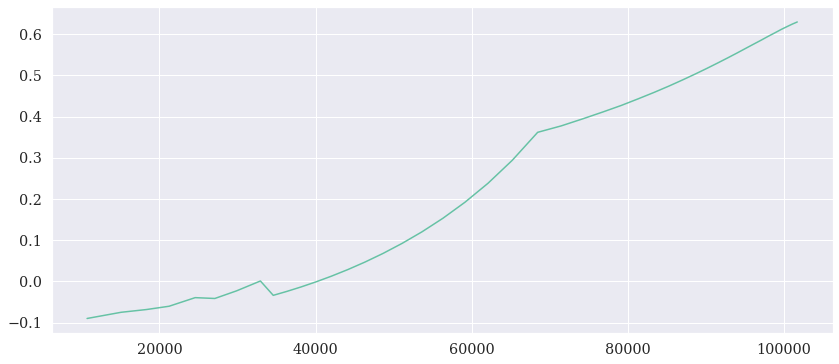

In [300]:
plt.figure(figsize=  (14,6))
plt.plot(p.t[1:,19000]/p.units.yr,-p.vg[1:,19000]- p.env._vg[1000,:45])

In [298]:
p.vg[:,19000]

array([   0.        ,  130.026044  ,  309.36815354,  396.15138861,
        463.80399369,  530.11981162,  590.3484836 ,  642.76440561,
        698.50979486,  742.10287666,  772.50229476,  803.77755457,
        835.96530809,  869.12061106,  903.32596752,  938.69685835,
        975.39580575, 1013.64318715, 1053.73107568, 1096.04612805,
       1141.09054068, 1189.51745578, 1242.16994285, 1300.14871336,
       1359.16745753, 1422.19500971, 1487.72391834, 1555.67042392,
       1625.82606206, 1698.0337663 , 1772.12363539, 1847.97176499,
       1925.46174576, 2004.51019441, 2085.0549776 , 2167.03958716,
       2250.44607532, 2335.24481053, 2421.42982397, 2509.00434222,
       2597.95988582, 2688.31704681, 2780.08922095, 2873.28508255,
       2967.92989108, 3064.03631717])

In [299]:
p.env._vg[1000,:45]

array([ -129.93625777,  -309.29337808,  -396.08329532,  -463.74386482,
        -530.08054832,  -590.30719725,  -642.74156703,  -698.51091909,
        -742.06921734,  -772.47809154,  -803.76412115,  -835.96412593,
        -869.13341703,  -903.35474502,  -938.74392932,  -975.46387431,
       -1013.73551856, -1053.8515135 , -1096.19944788, -1141.28259235,
       -1189.75559758, -1242.46372729, -1300.51042643, -1359.54471157,
       -1422.58950003, -1488.13500275, -1556.09745305, -1626.26936181,
       -1698.49255663, -1772.59758523, -1848.46051769, -1925.96469682,
       -2005.02681101, -2085.58471561, -2167.58175271, -2251.00008963,
       -2335.81012237, -2422.00562219, -2509.5897977 , -2598.55470249,
       -2688.92016284, -2780.70032165, -2873.9029993 , -2968.55401884,
       -3064.66567932])

In [292]:
p.vg[:,19000].shape

(46,)

In [284]:
p.t.shape

(46, 77805)

In [ ]:
plt.figure(figsize = (14,6))
plt.plot(np.cumsum(sphere.dt*0.01/p.units.AU) ,label = '0.01 error')
plt.plot(np.cumsum(sphere.dt*0.1 /p.units.AU) ,label = '+0.1 error')
plt.plot(np.cumsum(sphere.dt*1   /p.units.AU) ,label = '+1 error')
plt.title('Cumulative radius change due to an error in velocity')
plt.legend()
plt.ylabel('cumulative radius gain [AU]')
plt.xlabel('iterations')

plt.yscale('log') # <--- scale


plt.show()

In [267]:
p.r[0][19000]/p.units.AU

360.639298086498

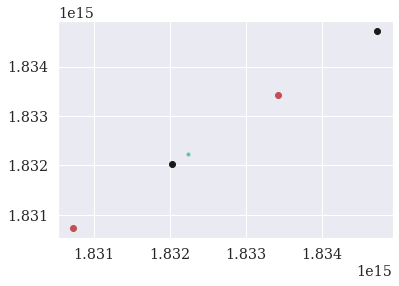

In [221]:
i = 45
plt.plot(p.env._rc[1000:1002,i],p.env._rc[1000:1002,i],'ko')
plt.plot(p.env._re[1000:1002,i],p.env._re[1000:1002,i],'ro')
plt.plot(p.r[i,19000],p.r[i,19000],'.')
#plt.plot(rr,rr,'g*', markersize = 10)
#plt.plot(rrr,rrr,'*',color= 'gray', markersize = 10)

In [ ]:
    def drag(self, r, s,rho_d = 1.6):
        """
        This is actually the inverse stopping time.
        so drag = 1/t_s
        rho_d = 1.6 g/cm^3
        """
        rm    = magnitude(r,True)
        rho_g = self.rho(rm)
        vth   = np.sqrt(8/np.pi)*self.Cs(rm)
        return rho_g*vth/(rho_d*s)

In [198]:
p.r[:,19000]

array([5.40237669e+15, 5.35838875e+15, 5.31578513e+15, 5.27514306e+15,
       5.23283842e+15, 5.17686103e+15, 5.12993555e+15, 5.07360498e+15,
       5.00611310e+15, 4.96755194e+15, 4.92540306e+15, 4.87935467e+15,
       4.82906725e+15, 4.77417086e+15, 4.71426062e+15, 4.64889113e+15,
       4.57756905e+15, 4.49974353e+15, 4.41479400e+15, 4.32201390e+15,
       4.22058970e+15, 4.10957289e+15, 3.98784321e+15, 3.85405818e+15,
       3.72498961e+15, 3.60012394e+15, 3.47949854e+15, 3.36298027e+15,
       3.25044799e+15, 3.14177650e+15, 3.03684043e+15, 2.93551428e+15,
       2.83767390e+15, 2.74319762e+15, 2.65196613e+15, 2.56386426e+15,
       2.47877981e+15, 2.39660479e+15, 2.31723515e+15, 2.24057052e+15,
       2.16651455e+15, 2.09497464e+15, 2.02586141e+15, 1.95908923e+15,
       1.89457570e+15, 1.83224158e+15])

In [273]:
print('0.001 dtsnap')
i = 19000
for i in range(100,200):
    print(i)
    print("\t Particle:\t",-p1.vg[i,19000])
    print("\t gas:     \t",p1.env._vg[1000,i-1])

0.001 dtsnap
100
	 Particle:	 -11272.933452631816
	 gas:     	 -11273.258406129222
101
	 Particle:	 -11487.93866338382
	 gas:     	 -11488.263662174164
102
	 Particle:	 -11705.716388580291
	 gas:     	 -11706.041244442573
103
	 Particle:	 -11926.301770290662
	 gas:     	 -11926.626348915852
104
	 Particle:	 -12149.711962881376
	 gas:     	 -12150.036074336313
105
	 Particle:	 -12375.947049218017
	 gas:     	 -12376.27052503184
106
	 Particle:	 -12604.999238492353
	 gas:     	 -12605.321877772301
107
	 Particle:	 -12836.85054610123
	 gas:     	 -12837.172196235075
108
	 Particle:	 -13071.466549431918
	 gas:     	 -13071.78705751523
109
	 Particle:	 -13308.83356631405
	 gas:     	 -13309.152747644272
110
	 Particle:	 -13548.984562277743
	 gas:     	 -13549.30229908405
111
	 Particle:	 -13791.890840503102
	 gas:     	 -13792.206939239493
112
	 Particle:	 -14037.48862755244
	 gas:     	 -14037.802904298796
113
	 Particle:	 -14285.665915251491
	 gas:     	 -14285.983911082341
114
	 Particle

In [274]:
i = 19000
print('0.001 dtsnap')
for i in range(0,45):
    print(i)
    print("\t Particle:\t",-p.vg[i,19000])
    print("\t gas:     \t",p.env._vg[1000,i-1])

0.001 dtsnap
0
	 Particle:	 -0.0
	 gas:     	 -3667.44279166
1
	 Particle:	 -130.02604399945628
	 gas:     	 -129.9362577733491
2
	 Particle:	 -309.36815353740127
	 gas:     	 -309.29337807523603
3
	 Particle:	 -396.15138861121466
	 gas:     	 -396.0832953211065
4
	 Particle:	 -463.80399369403415
	 gas:     	 -463.7438648227492
5
	 Particle:	 -530.1198116160831
	 gas:     	 -530.0805483182605
6
	 Particle:	 -590.3484836025359
	 gas:     	 -590.3071972506596
7
	 Particle:	 -642.7644056125586
	 gas:     	 -642.741567026703
8
	 Particle:	 -698.5097948631285
	 gas:     	 -698.5109190867432
9
	 Particle:	 -742.1028766581601
	 gas:     	 -742.0692173396875
10
	 Particle:	 -772.5022947620806
	 gas:     	 -772.4780915360403
11
	 Particle:	 -803.7775545705609
	 gas:     	 -803.7641211541498
12
	 Particle:	 -835.9653080942217
	 gas:     	 -835.9641259298821
13
	 Particle:	 -869.1206110563325
	 gas:     	 -869.1334170272071
14
	 Particle:	 -903.3259675199137
	 gas:     	 -903.3547450175548
15
	 P